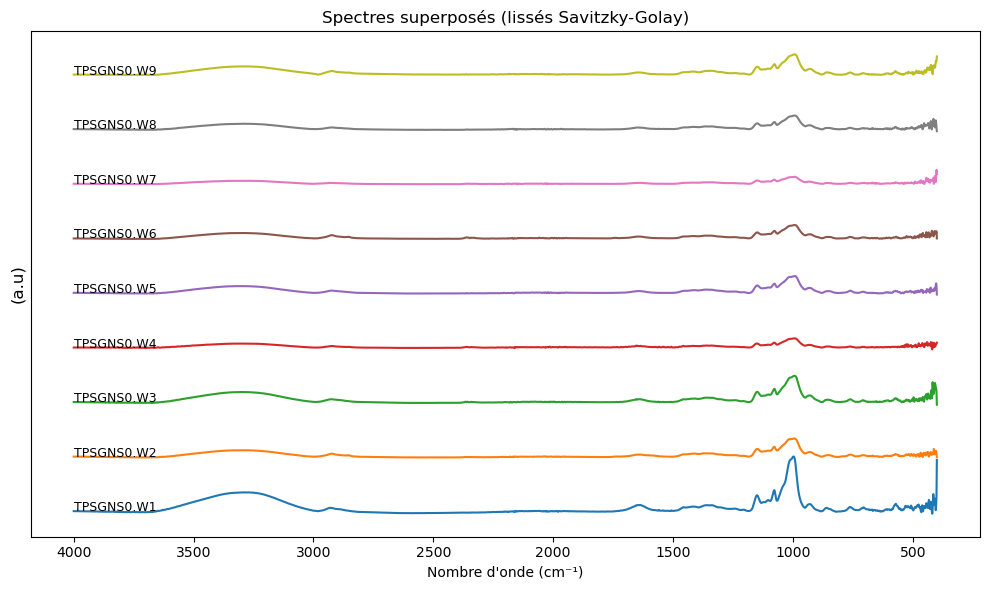

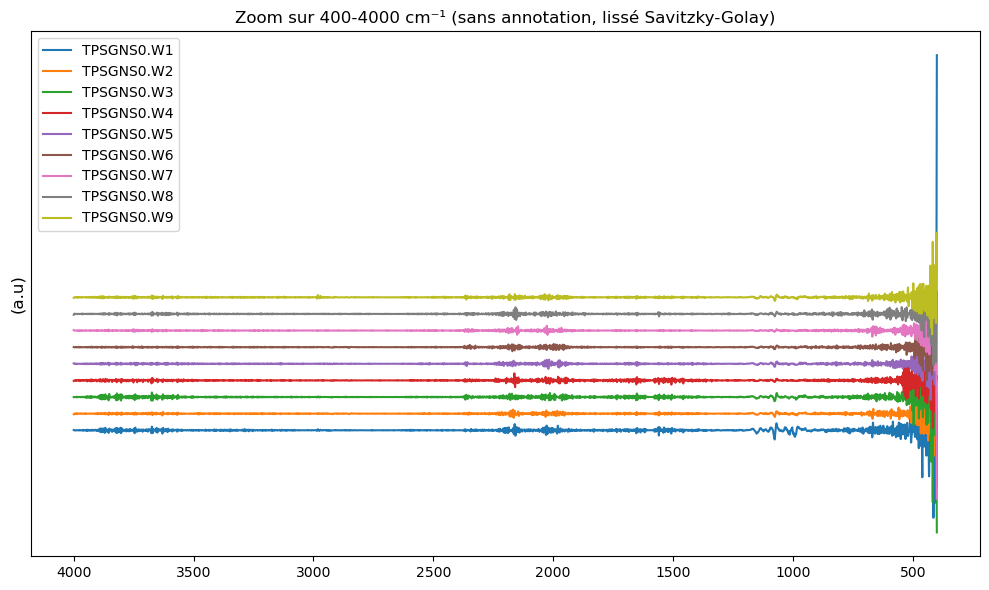

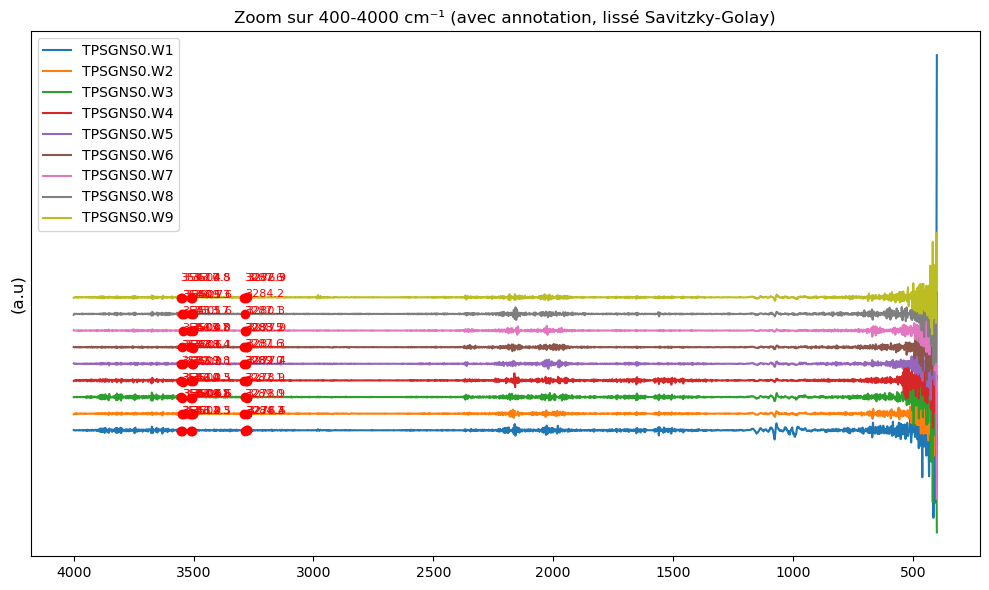

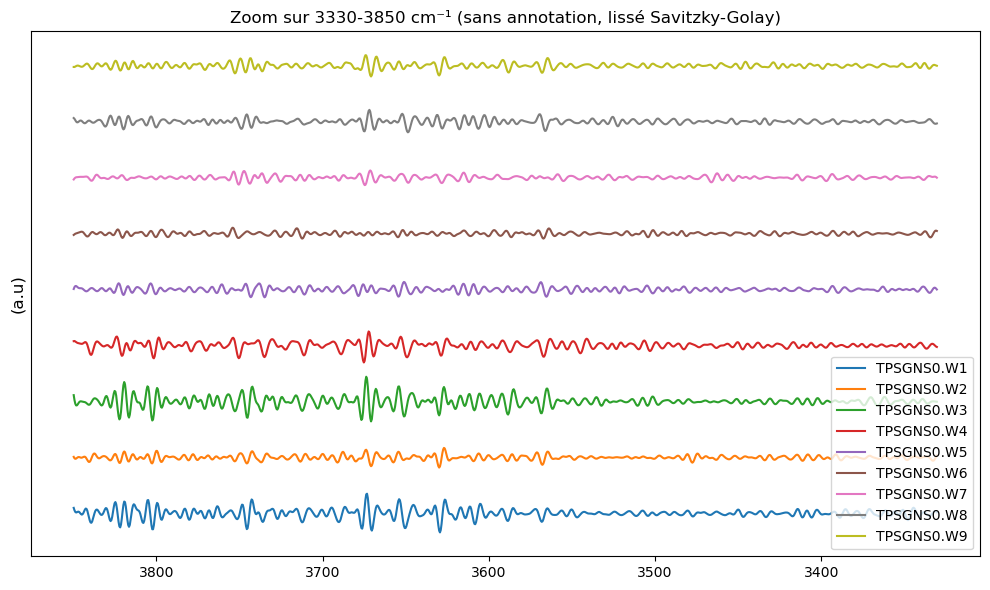

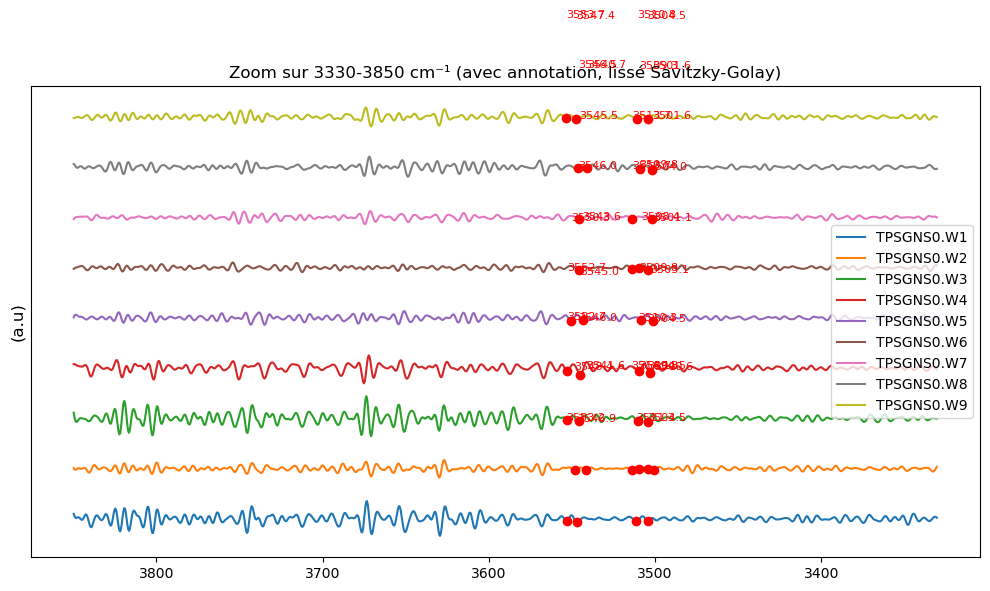

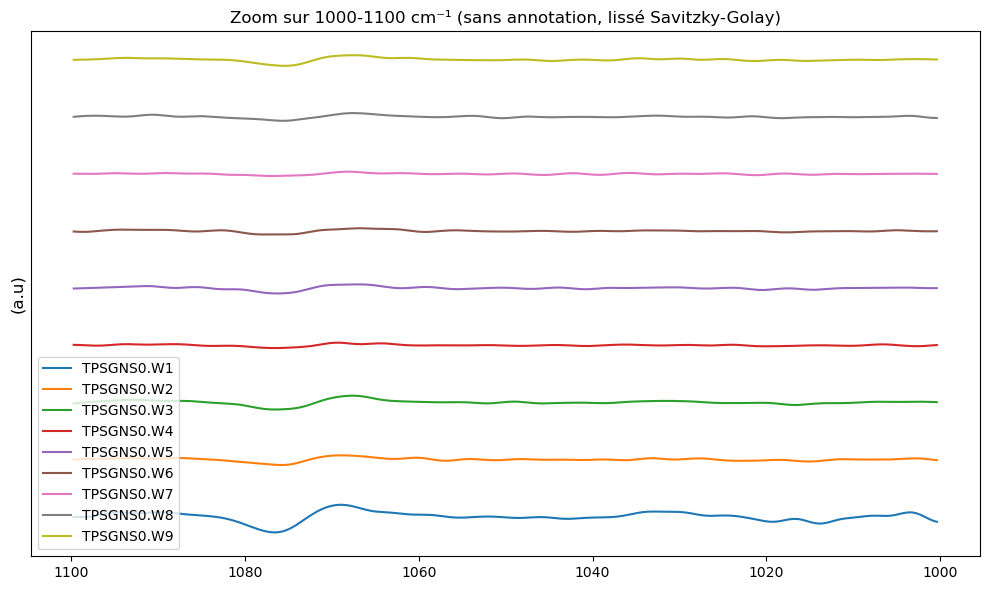

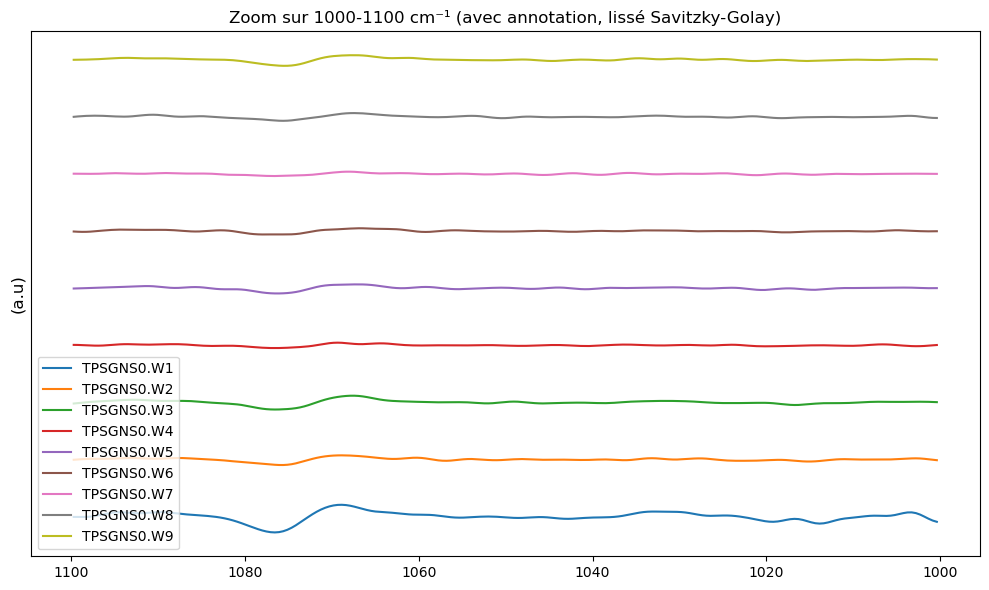

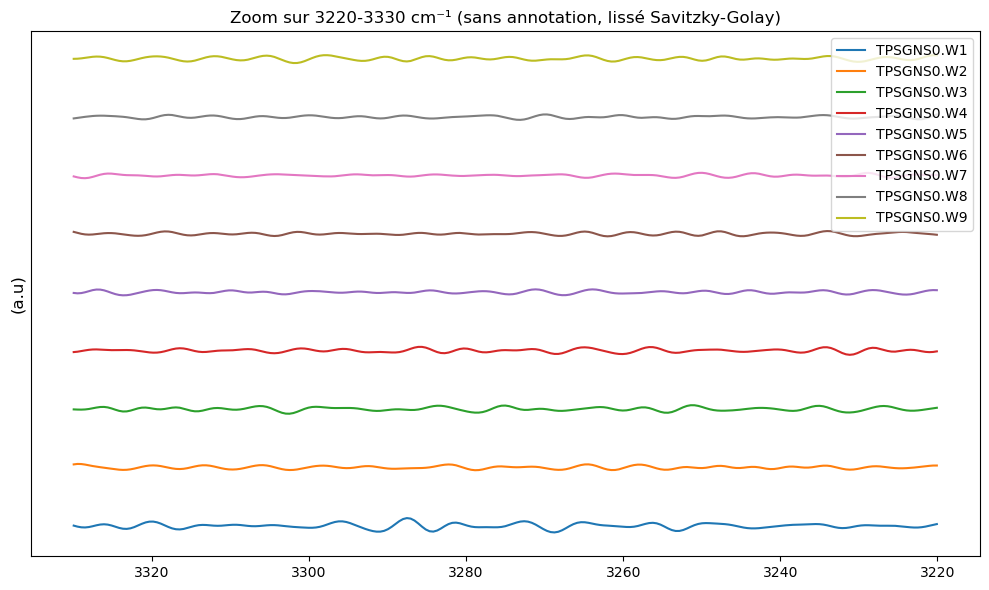

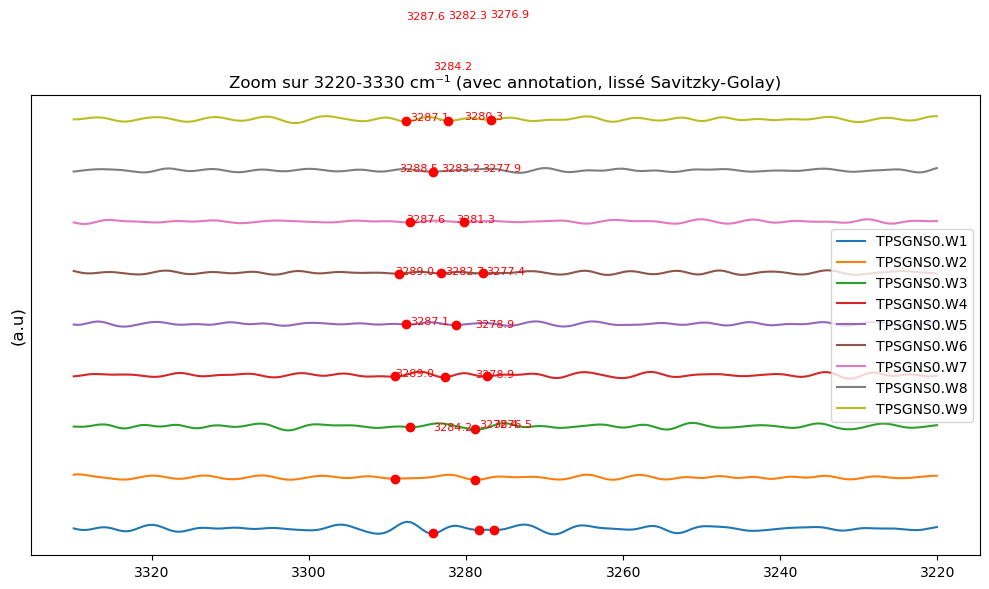

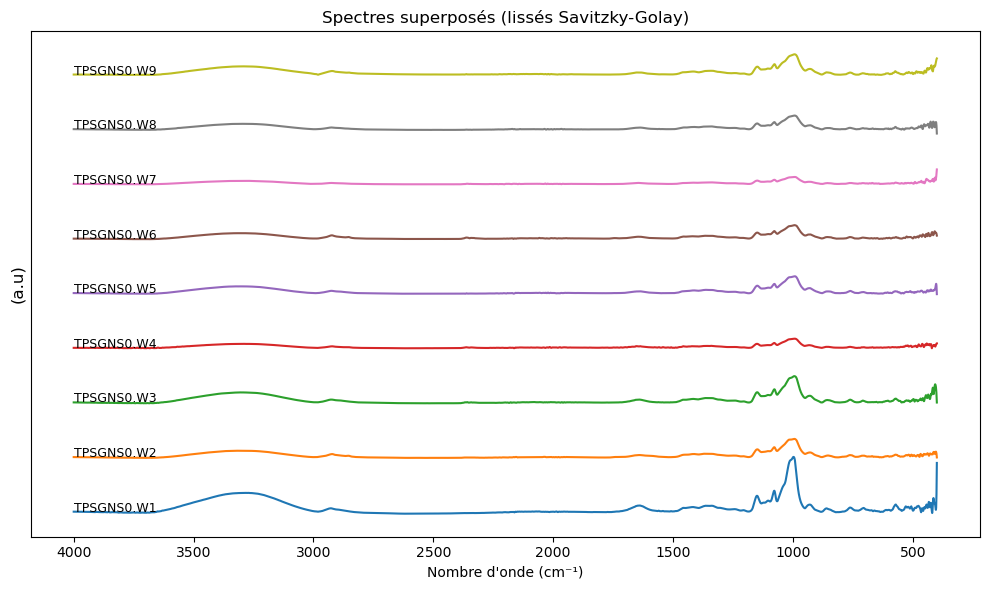

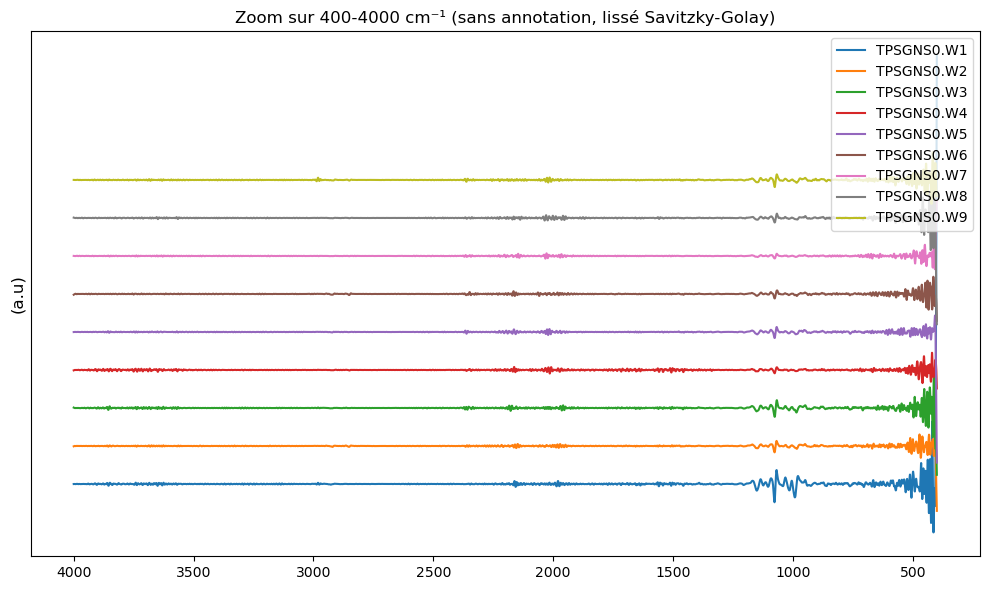

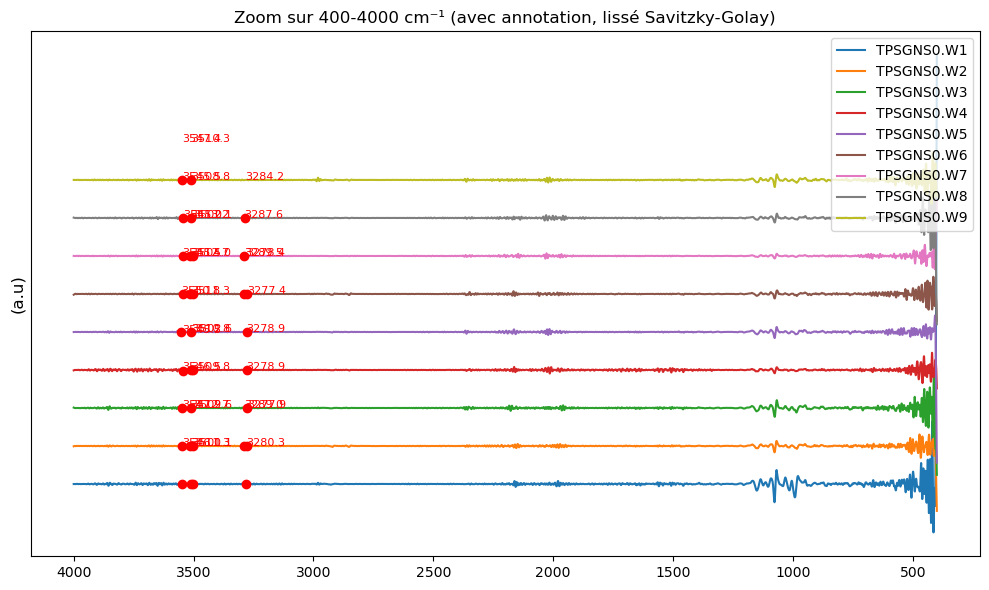

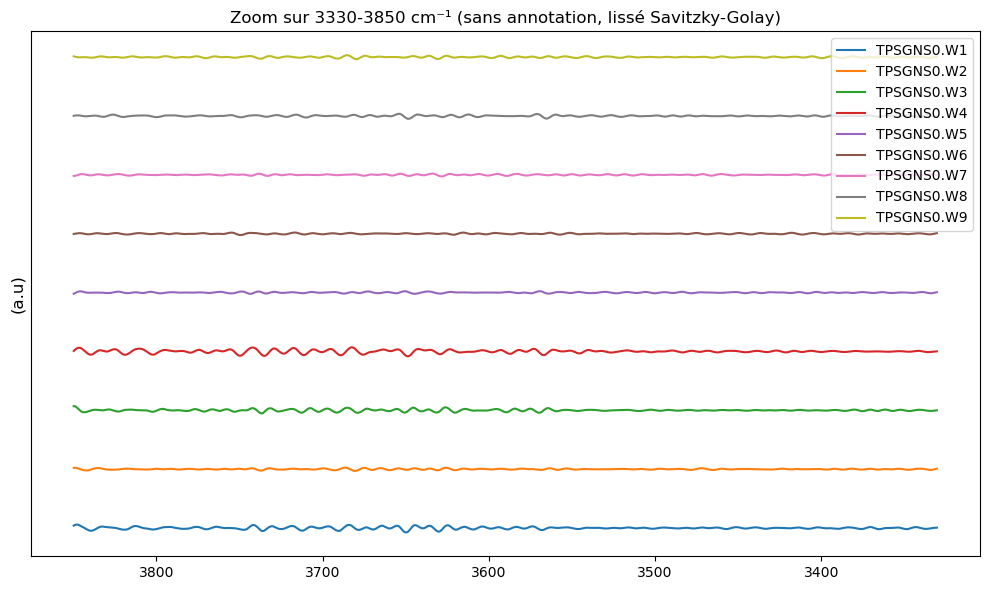

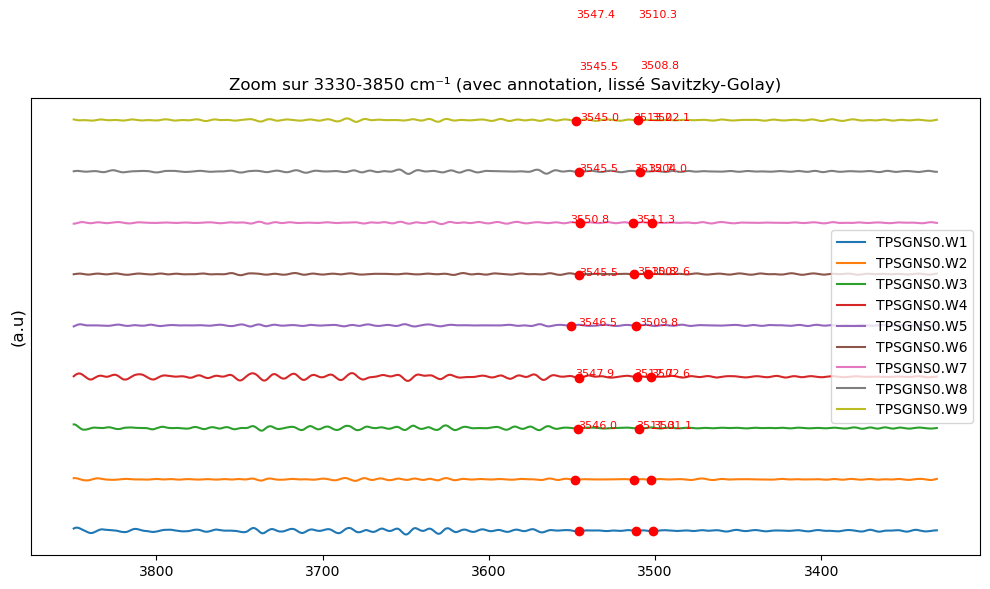

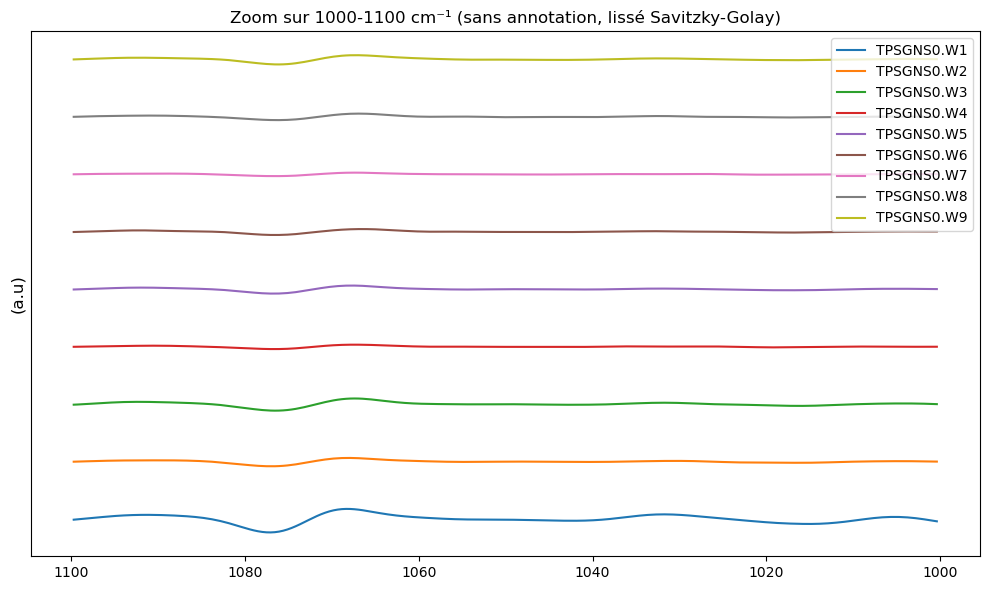

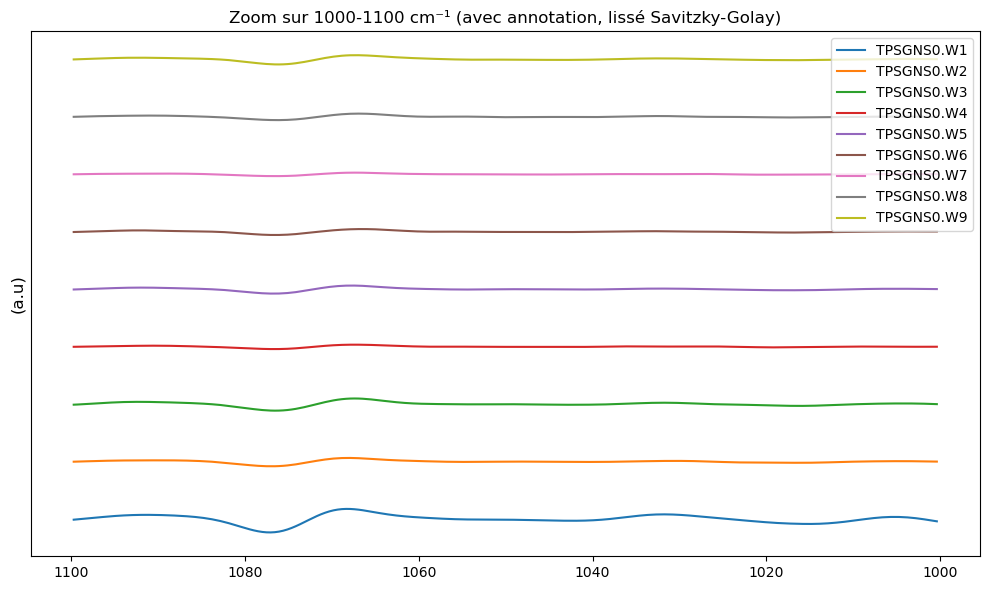

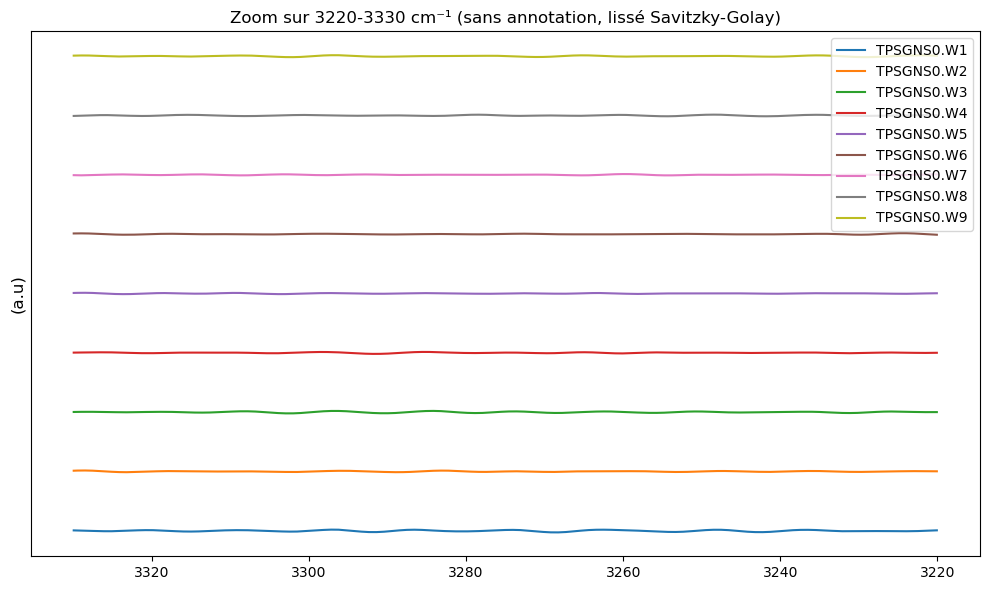

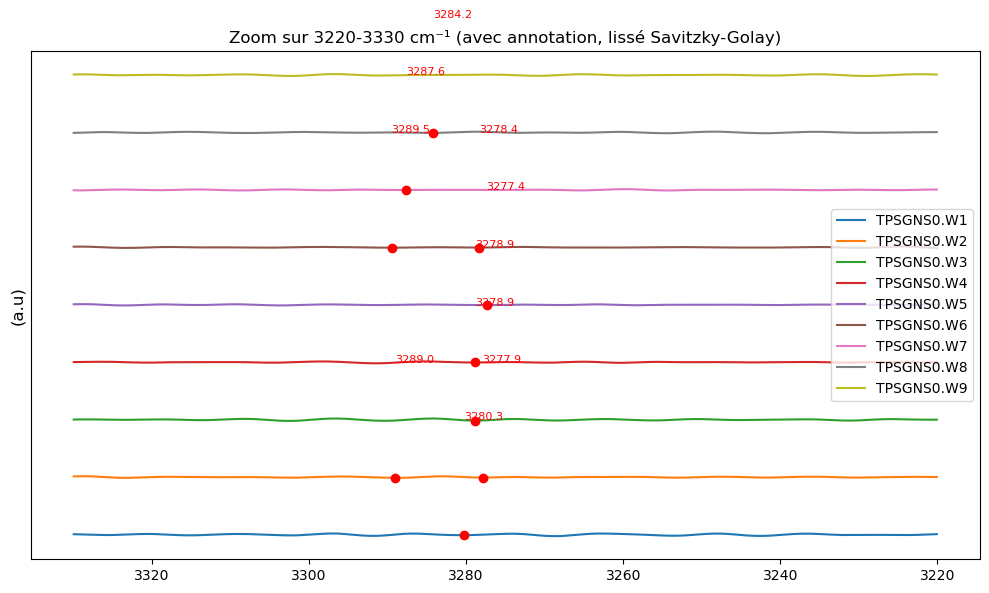

In [ ]:
import tkinter as tk
from tkinter import filedialog, ttk, messagebox, simpledialog
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.signal import find_peaks, savgol_filter
import os

# ------------------------------------------------------------
# Création du dossier de sauvegarde pour TOUTES les sorties
# ------------------------------------------------------------
DOSSIER_RESULTATS = "resultats_FTIR"
if not os.path.exists(DOSSIER_RESULTATS):
    os.makedirs(DOSSIER_RESULTATS)

# Paramètres globaux
tolerance = 0.5
x_1047, x_1022 = 1047, 1022
k_inverse = 262.5
v0_E = 3650
v0_D = 3600

# Paramètres Savitzky-Golay
savgol_window = 11
savgol_polyorder = 3

def calcul_deriv2(x, y):
    # Appliquer le filtre Savitzky-Golay avant de calculer la dérivée seconde
    y_smooth = savgol_filter(y, window_length=savgol_window, polyorder=savgol_polyorder)
    
    d2y = np.full_like(y_smooth, np.nan)
    for j in range(1, len(y_smooth) - 1):
        dx = x[j + 1] - x[j]
        if dx != 0:
            d2y[j] = (y_smooth[j + 1] - 2 * y_smooth[j] + y_smooth[j - 1]) / dx ** 2
    
    # Appliquer un second filtre Savitzky-Golay sur la dérivée seconde pour plus de lissage
    d2y_smooth = savgol_filter(d2y[~np.isnan(d2y)], window_length=savgol_window, polyorder=savgol_polyorder)
    d2y[~np.isnan(d2y)] = d2y_smooth
    
    return d2y

def calcul_E_D_RD(df, nu):
    y1047 = df[(df['X'] >= x_1047 - tolerance) & (df['X'] <= x_1047 + tolerance)]['Y'].max()
    y1022 = df[(df['X'] >= x_1022 - tolerance) & (df['X'] <= x_1022 + tolerance)]['Y'].max()
    RD = y1047 / y1022 if y1022 > 0 else None
    E = k_inverse * (v0_E - nu) / v0_E
    D = 2.84 - (v0_D - nu) / 4430
    return round(E, 4), round(D, 5), round(RD, 4) if RD else "N/A"

def detecter_pics(df, zones_pics):
    x = df['X'].values
    y = df['Y'].values
    
    # Appliquer un lissage Savitzky-Golay avant la détection des pics
    y_smooth = savgol_filter(y, window_length=savgol_window, polyorder=savgol_polyorder)
    
    # Calculer la dérivée seconde du signal lissé
    d2y = calcul_deriv2(x, y_smooth)
    df['d2Y'] = d2y
    
    pics = []
    for (p_start, p_end) in zones_pics:
        mask = (df['X'] >= min(p_start, p_end)) & (df['X'] <= max(p_start, p_end))
        x_zone = df.loc[mask, 'X'].values
        y_zone = df.loc[mask, 'd2Y'].values
        y_inv = -y_zone
        
        # Ajuster la hauteur minimale pour la détection des pics en fonction de l'amplitude du signal
        height_threshold = np.max(y_inv) * 0.1  # 10% du maximum
        
        peaks, _ = find_peaks(y_inv, height=height_threshold)
        for peak in peaks:
            x_val = round(x_zone[peak], 1)
            if x_val not in pics:
                pics.append(x_val)
    return sorted(pics)

class FTIRApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Interface FTIR Complète avec Savitzky-Golay")
        self.root.geometry("1000x700")

        self.notebook = ttk.Notebook(self.root)
        self.notebook.pack(fill="both", expand=True)

        self.init_tab1()
        self.init_tab2()
        self.init_tab3()

        # Champs pour les paramètres Savitzky-Golay
        frame_savgol = tk.Frame(self.tab1)
        frame_savgol.pack(pady=5)
        
        tk.Label(frame_savgol, text="Fenêtre Savitzky-Golay").grid(row=0, column=0, padx=5)
        self.entry_savgol_window = tk.Entry(frame_savgol, width=8)
        self.entry_savgol_window.insert(0, str(savgol_window))
        self.entry_savgol_window.grid(row=0, column=1, padx=5)
        
        tk.Label(frame_savgol, text="Ordre polynomial").grid(row=0, column=2, padx=5)
        self.entry_savgol_polyorder = tk.Entry(frame_savgol, width=8)
        self.entry_savgol_polyorder.insert(0, str(savgol_polyorder))
        self.entry_savgol_polyorder.grid(row=0, column=3, padx=5)

        # Champs dynamiques lignes début/fin
        frame_lignes = tk.Frame(self.tab1)
        frame_lignes.pack(pady=5)

        tk.Label(frame_lignes, text="Ligne de début").grid(row=0, column=0, padx=5)
        self.entry_debut = tk.Entry(frame_lignes, width=8)
        self.entry_debut.insert(0, "18")
        self.entry_debut.grid(row=0, column=1, padx=5)

        tk.Label(frame_lignes, text="Ligne de fin").grid(row=0, column=2, padx=5)
        self.entry_fin = tk.Entry(frame_lignes, width=8)
        self.entry_fin.insert(0, "7489")
        self.entry_fin.grid(row=0, column=3, padx=5)

        tk.Label(self.tab1, text="Zones de zoom (ex: 400-4000,3330-3850)").pack()
        self.entry_zoom = tk.Entry(self.tab1, width=80)
        self.entry_zoom.insert(0, "400-4000,3330-3850")
        self.entry_zoom.pack(pady=3)

        tk.Label(self.tab1, text="Zones de pics (ex: 3555-3540,3290-3275)").pack()
        self.entry_pics = tk.Entry(self.tab1, width=80)
        self.entry_pics.insert(0, "3555-3540,3290-3275")
        self.entry_pics.pack(pady=3)

        tk.Label(self.tab1, text="Décalage vertical principal").pack()
        self.entry_decalage_principal = tk.Entry(self.tab1, width=10)
        self.entry_decalage_principal.insert(0, "0.7")
        self.entry_decalage_principal.pack(pady=3)

        tk.Label(self.tab1, text="Décalages verticaux par zoom (ex: 0.01,0.02)").pack()
        self.entry_decalages_zoom = tk.Entry(self.tab1, width=40)
        self.entry_decalages_zoom.insert(0, "0.01,0.02")
        self.entry_decalages_zoom.pack(pady=3)

        tk.Button(self.tab1, text="Charger et afficher", command=self.generer_graphes).pack(pady=10)

    def update_savgol_params(self):
        global savgol_window, savgol_polyorder
        try:
            savgol_window = int(self.entry_savgol_window.get())
            savgol_polyorder = int(self.entry_savgol_polyorder.get())
            
            # Validation des paramètres
            if savgol_window % 2 == 0:
                messagebox.showwarning("Attention", "La fenêtre Savitzky-Golay doit être impaire. Ajout de 1.")
                savgol_window += 1
                self.entry_savgol_window.delete(0, tk.END)
                self.entry_savgol_window.insert(0, str(savgol_window))
                
            if savgol_polyorder >= savgol_window:
                messagebox.showwarning("Attention", "L'ordre polynomial doit être inférieur à la taille de la fenêtre.")
                savgol_polyorder = savgol_window - 1
                self.entry_savgol_polyorder.delete(0, tk.END)
                self.entry_savgol_polyorder.insert(0, str(savgol_polyorder))
                
        except ValueError:
            messagebox.showerror("Erreur", "Les paramètres Savitzky-Golay doivent être des entiers.")
            return False
        return True

    def parse_zone_list(self, s):
        zones = []
        for pair in s.split(','):
            try:
                a, b = map(int, pair.strip().split('-'))
                zones.append((min(a, b), max(a, b)))
            except:
                continue
        return zones

    def parse_decalages_zoom(self, s, n):
        vals = s.split(',')
        decalages = []
        for v in vals:
            try:
                decalages.append(float(v))
            except:
                decalages.append(0.01)
        while len(decalages) < n:
            decalages.append(decalages[-1])
        return decalages[:n]

    def generer_graphes(self):
        # Mettre à jour les paramètres Savitzky-Golay
        if not self.update_savgol_params():
            return
            
        # Récupération des lignes début et fin
        try:
            ligne_debut = int(self.entry_debut.get())
            ligne_fin = int(self.entry_fin.get())
            if ligne_debut >= ligne_fin:
                messagebox.showerror("Erreur", "La ligne de début doit être inférieure à la ligne de fin.")
                return
        except:
            messagebox.showerror("Erreur", "Lignes de début et fin doivent être des entiers valides.")
            return

        zooms = self.parse_zone_list(self.entry_zoom.get())
        zones_pics = self.parse_zone_list(self.entry_pics.get())
        fichiers = filedialog.askopenfilenames(filetypes=[("Fichiers CSV", "*.csv")])
        if not fichiers:
            return

        decalage_principal = float(self.entry_decalage_principal.get())
        decalages_zoom = self.parse_decalages_zoom(self.entry_decalages_zoom.get(), len(zooms))
        couleurs = [cm.tab10(i % 10) for i in range(len(fichiers))]
        spectres = []

        for i, chemin in enumerate(fichiers):
            df = pd.read_csv(chemin).iloc[ligne_debut:ligne_fin].rename(columns={"TITLE": "X", "Unnamed: 1": "Y"})
            df["X"] = pd.to_numeric(df["X"], errors="coerce")
            df["Y"] = pd.to_numeric(df["Y"], errors="coerce")
            df = df.dropna()
            
            # Appliquer un lissage Savitzky-Golay sur les données Y
            y_smooth = savgol_filter(df["Y"].values, window_length=savgol_window, polyorder=savgol_polyorder)
            df["Y"] = y_smooth
            
            df["d2Y"] = calcul_deriv2(df["X"].values, df["Y"].values)
            df["Y_offset"] = df["Y"] + i * decalage_principal
            nom_sans_ext = os.path.splitext(os.path.basename(chemin))[0]
            spectres.append({"df": df, "nom": nom_sans_ext, "couleur": couleurs[i]})

        plt.figure(figsize=(10, 6))
        plt.yticks([])
        plt.ylabel("(a.u)", fontsize=12)
        for sp in spectres:
            plt.plot(sp["df"]["X"], sp["df"]["Y_offset"], color=sp["couleur"])
            plt.text(sp["df"]["X"].iloc[-1], sp["df"]["Y_offset"].iloc[-1], sp["nom"], fontsize=9)
        plt.title("Spectres superposés (lissés Savitzky-Golay)")
        plt.xlabel("Nombre d'onde (cm⁻¹)")
        plt.gca().invert_xaxis()
        plt.tight_layout()
        plt.savefig(os.path.join(DOSSIER_RESULTATS, f"Spectres superposés"), dpi=300)
        plt.show()

        for idx, (start, end) in enumerate(zooms):
            zones_pics_in_zoom = [(ps, pe) for ps, pe in zones_pics if min(ps, pe) >= start and max(ps, pe) <= end]

            # Figure sans annotation
            plt.figure(figsize=(10, 6))
            plt.yticks([])
            plt.ylabel("(a.u)", fontsize=12)
            for i, sp in enumerate(spectres):
                df = sp["df"]
                mask = (df["X"] >= start) & (df["X"] <= end)
                if df.loc[mask].empty:
                    continue
                y_zoom = df.loc[mask, "d2Y"] + i * decalages_zoom[idx]
                x_zoom = df.loc[mask, "X"]
                plt.plot(x_zoom, y_zoom, label=sp["nom"], color=sp["couleur"])
            plt.title(f"Zoom sur {start}-{end} cm⁻¹ (sans annotation, lissé Savitzky-Golay)")
            plt.gca().invert_xaxis()
            plt.tight_layout()
            plt.legend()
            plt.savefig(os.path.join(DOSSIER_RESULTATS, f"zoom_{start}_{end}_no_annotation.png"), dpi=300)
            plt.show()

            # Figure avec annotation
            plt.figure(figsize=(10, 6))
            plt.yticks([])
            plt.ylabel("(a.u)", fontsize=12)
            for i, sp in enumerate(spectres):
                df = sp["df"]
                mask = (df["X"] >= start) & (df["X"] <= end)
                if df.loc[mask].empty:
                    continue
                y_zoom = df.loc[mask, "d2Y"] + i * decalages_zoom[idx]
                x_zoom = df.loc[mask, "X"]
                plt.plot(x_zoom, y_zoom, label=sp["nom"], color=sp["couleur"])

                for zps, zpe in zones_pics_in_zoom:
                    pics_detectes = detecter_pics(df, [(zps, zpe)])
                    for x_pic in pics_detectes:
                        try:
                            y_pic = float(df.loc[np.isclose(df["X"], x_pic, atol=0.5), "d2Y"].values[0]) + i * decalages_zoom[idx]
                            plt.plot(x_pic, y_pic, "ro")
                            plt.text(x_pic, y_pic + 0.01, f"{x_pic}", color="red", fontsize=8)
                        except IndexError:
                            continue
            plt.title(f"Zoom sur {start}-{end} cm⁻¹ (avec annotation, lissé Savitzky-Golay)")
            plt.gca().invert_xaxis()
            plt.tight_layout()
            plt.legend()
            plt.savefig(os.path.join(DOSSIER_RESULTATS, f"zoom_{start}_{end}_annotated.png"), dpi=300)
            plt.show()

    def init_tab1(self):
        self.tab1 = ttk.Frame(self.notebook)
        self.notebook.add(self.tab1, text="Visualisation spectres")

    def init_tab2(self):
        self.tab2 = ttk.Frame(self.notebook)
        self.notebook.add(self.tab2, text="Analyse avancée")
        tk.Button(self.tab2, text="Ouvrir l'analyse avancée", command=self.lancer_analyse).pack(pady=20)

    def init_tab3(self):
        self.tab3 = ttk.Frame(self.notebook)
        self.notebook.add(self.tab3, text="Analyse automatique")
        tk.Button(self.tab3, text="Lancer l'analyse automatique", command=self.lancer_auto_analyse).pack(pady=10)

    def lancer_analyse(self):
        # Mettre à jour les paramètres Savitzky-Golay
        if not self.update_savgol_params():
            return
            
        try:
            debut = int(self.entry_debut.get())
            fin = int(self.entry_fin.get())
            if debut >= fin:
                messagebox.showerror("Erreur", "La ligne de début doit être inférieure à la ligne de fin.")
                return
        except:
            messagebox.showerror("Erreur", "Lignes de début et fin doivent être des entiers valides.")
            return
        win = tk.Toplevel(self.root)
        InterfaceAvancee(win, ligne_debut=debut, ligne_fin=fin)

    def lancer_auto_analyse(self):
        # Mettre à jour les paramètres Savitzky-Golay
        if not self.update_savgol_params():
            return
            
        try:
            debut = int(self.entry_debut.get())
            fin = int(self.entry_fin.get())
            if debut >= fin:
                messagebox.showerror("Erreur", "La ligne de début doit être inférieure à la ligne de fin.")
                return
        except:
            messagebox.showerror("Erreur", "Lignes de début et fin doivent être des entiers valides.")
            return
        win = tk.Toplevel(self.root)
        InterfaceAuto(win, ligne_debut=debut, ligne_fin=fin)

class InterfaceAvancee:
    def __init__(self, master, ligne_debut=18, ligne_fin=7489):
        self.master = master
        self.master.title("Analyse FTIR avancée")
        self.ligne_debut = ligne_debut
        self.ligne_fin = ligne_fin

        self.fichiers_data = {}
        self.resultats = []

        frame_btn = ttk.Frame(master)
        frame_btn.pack(pady=10)
        ttk.Button(frame_btn, text="Charger fichiers CSV", command=self.charger_fichiers).pack(side="left", padx=5)
        ttk.Button(frame_btn, text="Exporter vers Excel", command=self.exporter_resultats).pack(side="left", padx=5)

        colonnes = ("Fichier", "Pic", "Type", "Utiliser")
        self.tree = ttk.Treeview(master, columns=colonnes, show="headings")
        for col in colonnes:
            self.tree.heading(col, text=col)
            self.tree.column(col, width=120, anchor="center")
        self.tree.pack(expand=True, fill="both")

        self.liaison_types = ["libre", "inter-brin", "inter-hélice", "autre"]
        self.tree.bind("<Double-1>", self.toggle_et_modifier)

    def charger_fichiers(self):
        fichiers = filedialog.askopenfilenames(filetypes=[("CSV", "*.csv")])
        if not fichiers:
            return
        for path in fichiers:
            nom = os.path.splitext(os.path.basename(path))[0]
            try:
                df = pd.read_csv(path).iloc[self.ligne_debut:self.ligne_fin].rename(columns={"TITLE": "X", "Unnamed: 1": "Y"})
                df['X'] = pd.to_numeric(df['X'], errors='coerce')
                df['Y'] = pd.to_numeric(df['Y'], errors='coerce')
                df = df.dropna()
                
                # Appliquer un lissage Savitzky-Golay
                y_smooth = savgol_filter(df['Y'].values, window_length=savgol_window, polyorder=savgol_polyorder)
                df['Y'] = y_smooth
                
                self.fichiers_data[nom] = df

                pics = detecter_pics(df, zones_pics=[(3555, 3540), (3515, 3500), (3290, 3275)])
                for pic in pics:
                    self.tree.insert("", "end", values=(nom, pic, self.liaison_types[0], "Non"))
            except Exception as e:
                messagebox.showerror("Erreur", f"{nom} : {e}")

    def exporter_resultats(self):
        self.resultats.clear()
        for item_id in self.tree.get_children():
            fichier, pic, type_liaison, utiliser = self.tree.item(item_id, "values")
            if utiliser == "Oui":
                try:
                    pic = float(pic)
                    df = self.fichiers_data[fichier]
                    E, D, RD = calcul_E_D_RD(df, pic)
                    self.resultats.append({
                        "Fichier": fichier,
                        "ν (cm⁻¹)": pic,
                        "Type de liaison": type_liaison,
                        "E (kJ/mol)": E,
                        "D (Å)": D,
                        "Abs1047/Abs1022 ": RD
                    })
                except:
                    continue
        if self.resultats:
            pd.DataFrame(self.resultats).to_excel(os.path.join(DOSSIER_RESULTATS, "resultats_avances_ftir.xlsx"), index=False)
            messagebox.showinfo("Export", "Exporté avec succès.")
        else:
            messagebox.showwarning("Vide", "Aucun résultat à exporter.")

    def toggle_et_modifier(self, event):
        item_id = self.tree.identify_row(event.y)
        col = self.tree.identify_column(event.x)
        if not item_id:
            return
        vals = list(self.tree.item(item_id, "values"))
        if col == "#4":  # Colonne "Utiliser"
            vals[3] = "Non" if vals[3] == "Oui" else "Oui"
        elif col == "#3":  # Colonne "Type"
            current_type = vals[2]
            if current_type == "autre":
                saisie = simpledialog.askstring("Type personnalisé", "Entrez un type de liaison :")
                if saisie:
                    vals[2] = saisie.strip()
            else:
                index = self.liaison_types.index(current_type) if current_type in self.liaison_types else 0
                vals[2] = self.liaison_types[(index + 1) % len(self.liaison_types)]
        self.tree.item(item_id, values=vals)

class InterfaceAuto:
    def __init__(self, master, ligne_debut=18, ligne_fin=7489):
        self.master = master
        self.master.title("Analyse automatique FTIR")
        self.ligne_debut = ligne_debut
        self.ligne_fin = ligne_fin

        self.fichiers_data = {}
        self.resultats = []

        tk.Button(master, text="Charger et analyser", command=self.charger_et_analyser).pack(pady=10)
        tk.Button(master, text="Exporter Excel", command=self.exporter).pack(pady=5)

        colonnes = ("Fichier", "Type", "ν (cm⁻¹)", "E (kJ/mol)", "D (nm)", "Abs1047/Abs1022 (a.u.)")
        self.tree = ttk.Treeview(master, columns=colonnes, show="headings")
        for col in colonnes:
            self.tree.heading(col, text=col)
            self.tree.column(col, width=100, anchor="center")
        self.tree.pack(expand=True, fill="both")

        self.zones_liaisons = {
            "libre": (3555, 3540),
            "inter-brin": (3515, 3500),
            "inter-hélice": (3290, 3275)
        }

    def charger_et_analyser(self):
        self.resultats.clear()
        fichiers = filedialog.askopenfilenames(filetypes=[("CSV", "*.csv")])
        if not fichiers:
            return
        for chemin in fichiers:
            nom = os.path.splitext(os.path.basename(chemin))[0]
            try:
                df = pd.read_csv(chemin).iloc[self.ligne_debut:self.ligne_fin].rename(columns={"TITLE": "X", "Unnamed: 1": "Y"})
                df['X'] = pd.to_numeric(df['X'], errors='coerce')
                df['Y'] = pd.to_numeric(df['Y'], errors='coerce')
                df = df.dropna()
                
                # Appliquer un lissage Savitzky-Golay
                y_smooth = savgol_filter(df['Y'].values, window_length=savgol_window, polyorder=savgol_polyorder)
                df['Y'] = y_smooth
                
                df["d2Y"] = calcul_deriv2(df["X"].values, df["Y"].values)
                self.fichiers_data[nom] = df

                for type_liaison, (p_start, p_end) in self.zones_liaisons.items():
                    mask = (df["X"] >= min(p_start, p_end)) & (df["X"] <= max(p_start, p_end))
                    if df.loc[mask, "d2Y"].empty:
                        continue
                    idx_min = df.loc[mask, "d2Y"].idxmin()
                    x_pic = round(df.loc[idx_min, "X"], 1)
                    E, D, RD = calcul_E_D_RD(df, x_pic)
                    self.resultats.append({
                        "Fichier": nom,
                        "Type": type_liaison,
                        "ν (cm⁻¹)": x_pic,
                        "E (kJ/mol)": E,
                        "D (Å)": D,
                        "Abs1047/Abs1022 ": RD
                    })
                    self.tree.insert("", "end", values=(nom, type_liaison, x_pic, E, D, RD))
            except Exception as e:
                messagebox.showerror("Erreur", f"{nom} : {e}")

    def exporter(self):
        if not self.resultats:
            messagebox.showwarning("Vide", "Aucun résultat à exporter.")
            return
        pd.DataFrame(self.resultats).to_excel(os.path.join(DOSSIER_RESULTATS, "resultats_automatiques_ftir.xlsx"), index=False)
        messagebox.showinfo("Export", "Export terminé.")

# -------- Lancement --------
if __name__ == "__main__":
    root = tk.Tk()
    app = FTIRApp(root)
    root.mainloop()